In [1]:
from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf

from starred.psf.psf import PSF, load_PSF_model
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
from SFstarred.DataStarred import DataStarred
from SFstarred.utils import save_npy

In [ ]:
%load_ext autoreload
%autoreload 2

## This notebook goes trough from the results from chapter 1 until obtain a PSF using the "the best method" from PSF_starred_v10

In [6]:
data_f160W = pd.read_pickle("data_for_starred/data_for_starred_F160_0214.pickle")

In [7]:
data_f160W.keys()

dict_keys(['data', 'data_weight', 'data_noisemaps', 'stars', 'noisemaps_stars', 'coord_pix_images', 'images_names', 'coord_pix_images_dict', 'selected_star_indices', 'non_selected_stars_index', 'norm_factor'])

In [8]:
# Setup parameters

# subsampling_factor control the resolution of the reconstructed psf
subsampling_factor = 2 #this can be increased for a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 1000 #300
n_iter = 4000 

# increasing lambda_scales and lambda_hf will increase chi2 (they should be between 1 and 3)
lambda_scales = 3.0 # control the regularization strength for low frequencies 
lambda_hf = 3.0 # (increse this) control the regularization strength for high frequencies 
lambda_positivity = 1000. #0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.

convolution_method = 'scipy'#'fft'#'scipy'  #fft is better on CPU

# Stars normalize, norm factor and sigma_2 normalize by norm**2
stars_norm_F160 = data_f160W["stars"]
#norm_F160W=Data_F160W["norm"]
stars_sigma_2_norm_F160 = data_f160W['noisemaps_stars']

# number of stars
N = len(stars_norm_F160)

# data dimensions
image_size = np.shape(stars_norm_F160)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(stars_norm_F160))

(4, 51, 51)


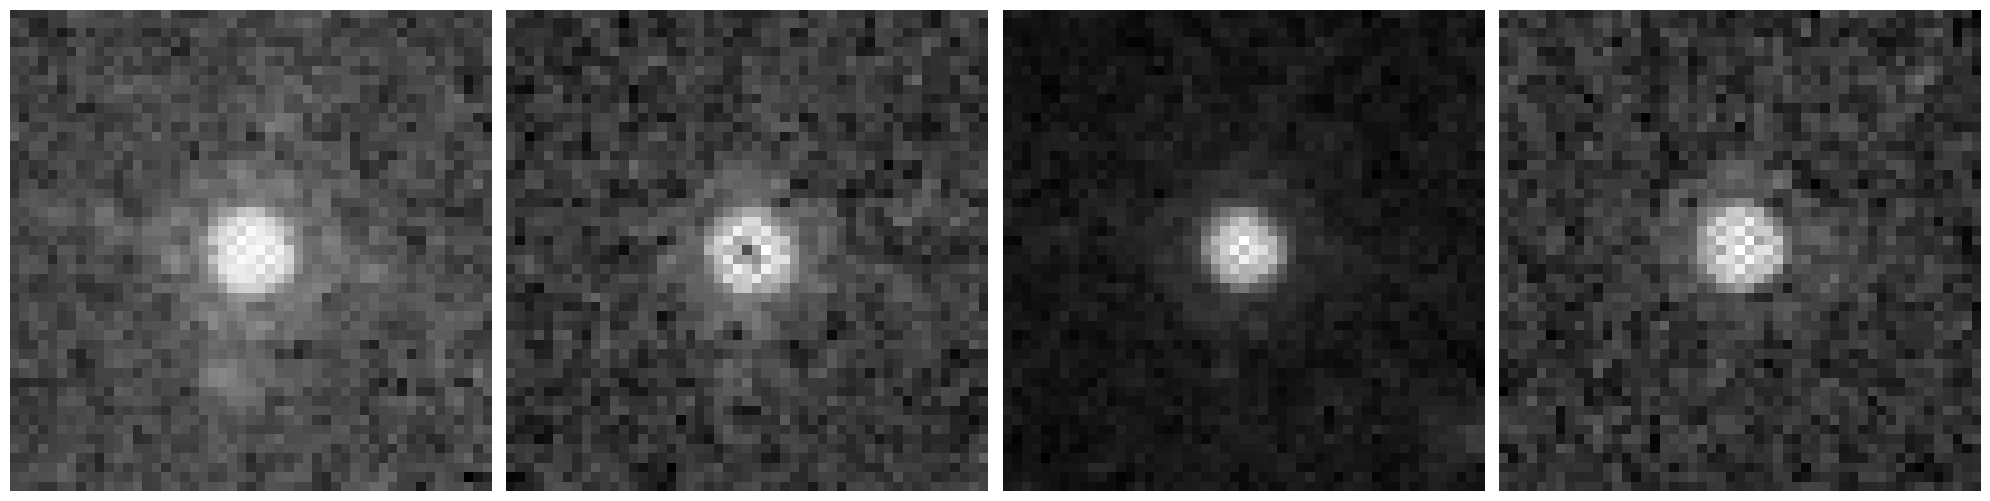

In [9]:
fig, axs = plt.subplots(1,4, figsize=(20,20))
for ax, star, noisemap in zip(axs, stars_norm_F160, stars_sigma_2_norm_F160):
    ax.imshow(star/noisemap, cmap='gray'); ax.axis('off')
plt.tight_layout()

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Step 1, fixing : ['background'] ###


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


Step 1/2 took 80 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([2.094166], dtype=float32), 'beta': Array([1.9081742], dtype=float32), 'C': Array([45.72054], dtype=float32)}, 'kwargs_gaussian': {'a': Array([112.80578,  67.84794,  80.19099,  64.21668], dtype=float32), 'x0': Array([-0.0425926 ,  0.36318633, -0.12413211,  0.28360206], dtype=float32), 'y0': Array([ 0.16742611,  0.18174917, -0.21665758, -0.3694842 ], dtype=float32)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  11258.185
Overall Reduced Chi2 :  2.1642032
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 2000/2000 [00:26<00:00, 76.33it/s] 


Step 2/2 took 27 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([2.094166], dtype=float32), 'beta': Array([1.9081742], dtype=float32), 'C': Array([45.72054], dtype=float32)}, 'kwargs_gaussian': {'a': Array([118.12849 ,  71.856926,  82.54334 ,  67.3742  ], dtype=float32), 'x0': Array([-0.02829741,  0.37640688, -0.11151689,  0.31060955], dtype=float32), 'y0': Array([ 0.1605639 ,  0.15094101, -0.23562281, -0.3887591 ], dtype=float32)}, 'kwargs_background': {'background': Array([-0.00265963, -0.00049745, -0.00226924, ..., -0.00286232,
       -0.00054978,  0.00264139], dtype=float32), 'mean': Array([0., 0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  7617.85
Overall Reduced Chi2 :  1.1429038
Moffat fit :


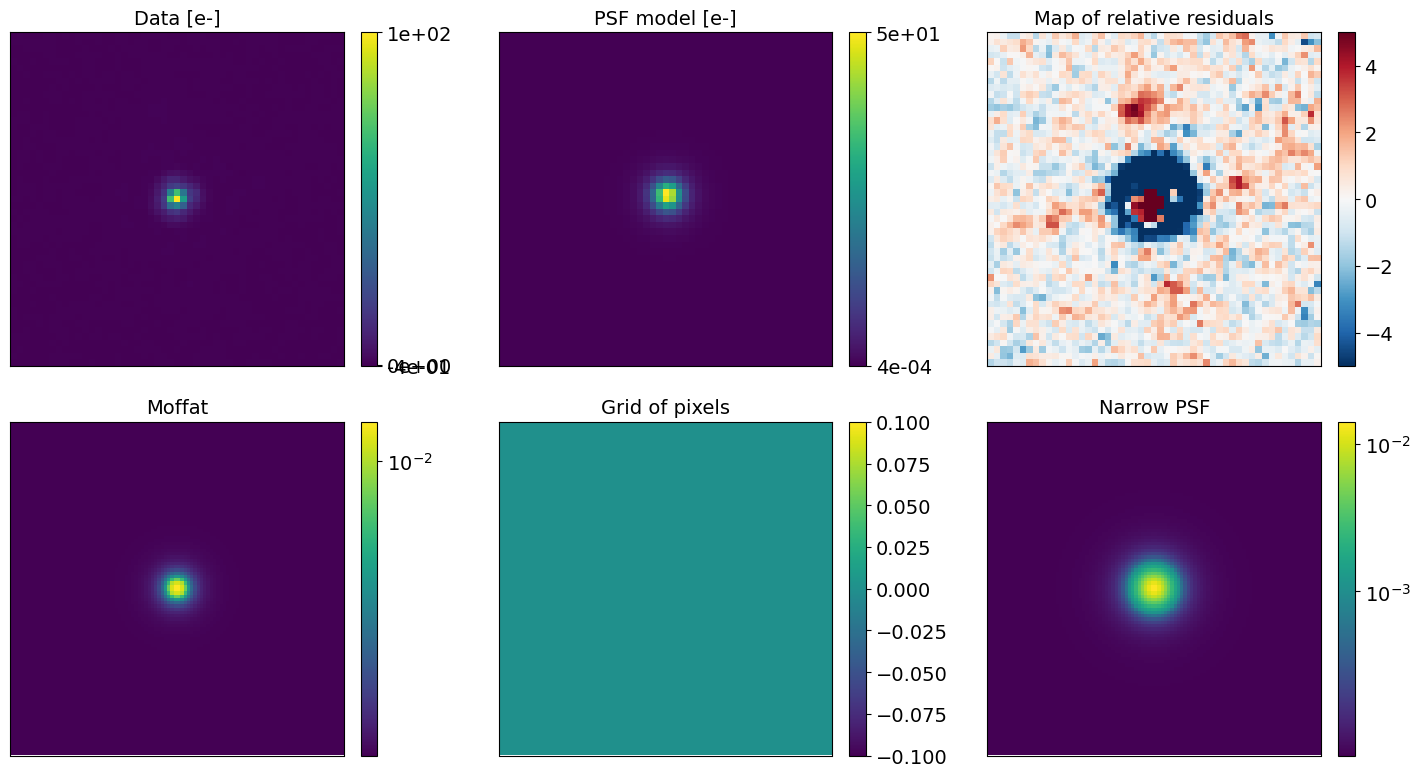

Moffat+ Background fit :


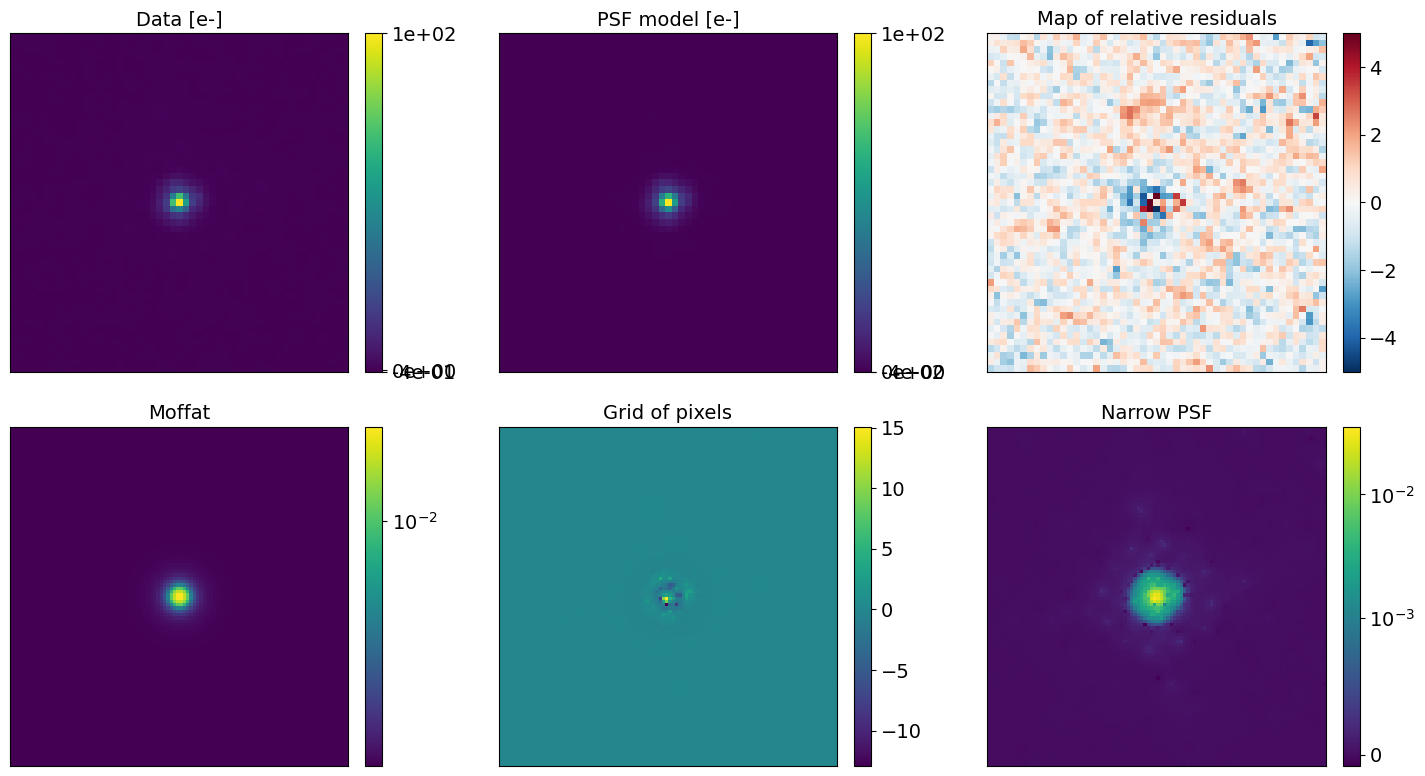

Multiple stars PSF model :


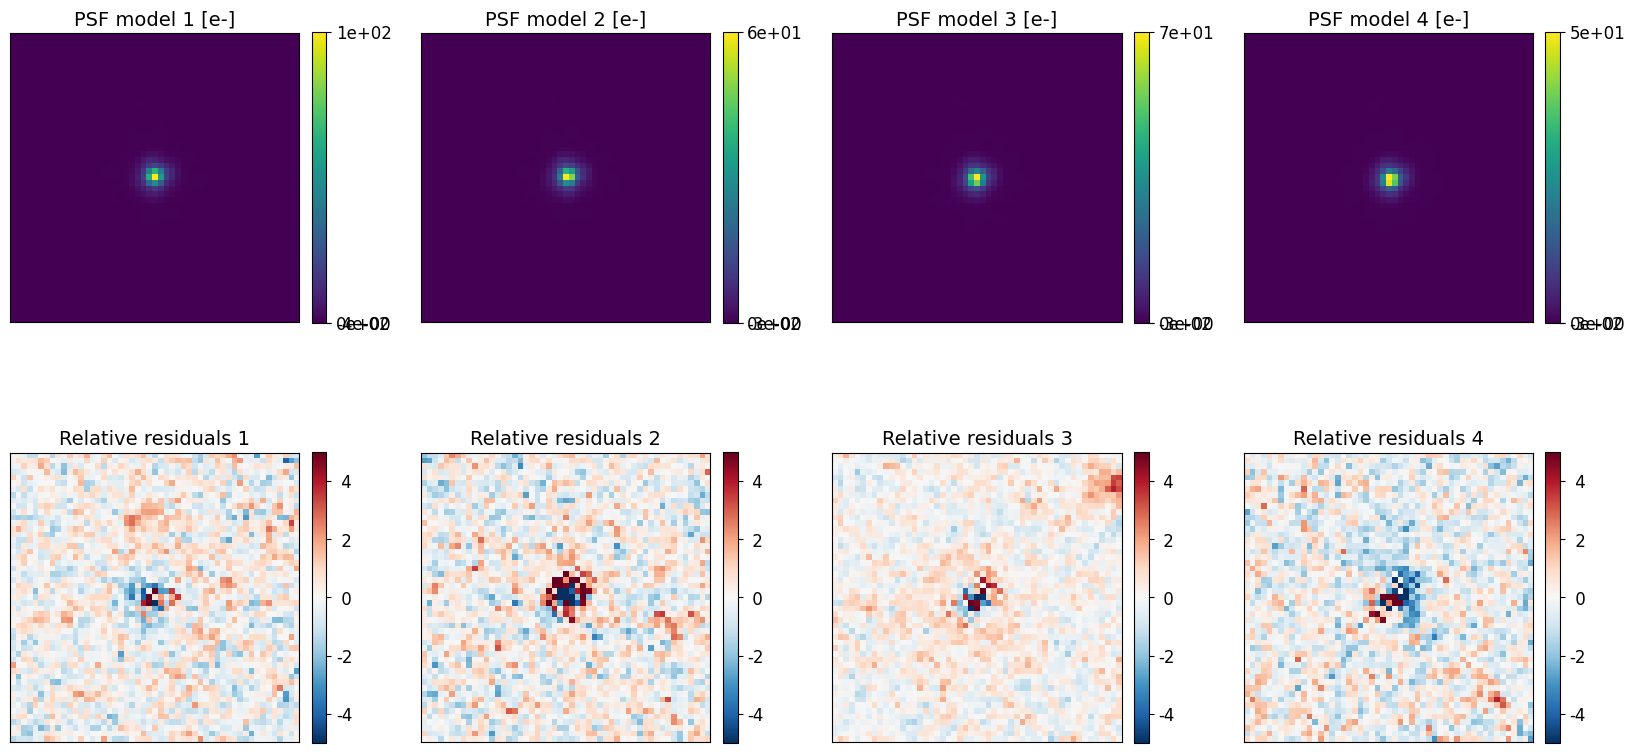

Loss history :


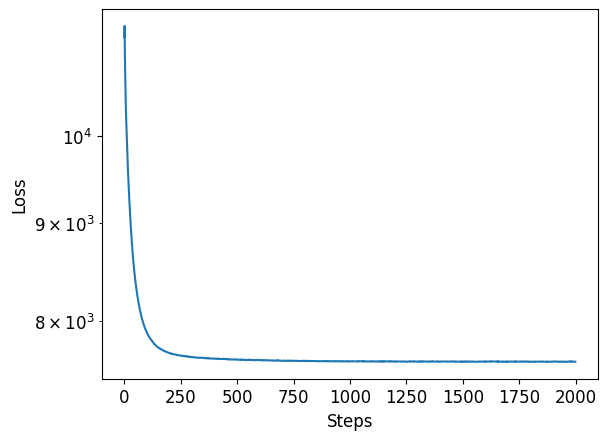

/tmp/ipykernel_3007/3142976097.py:56: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


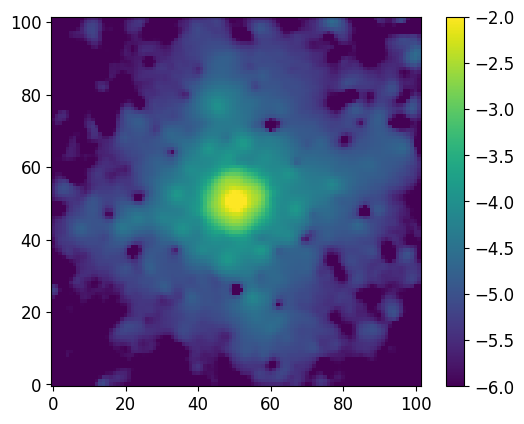

In [10]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(stars_norm_F160, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 2000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        stars_norm_F160, model,
        parameters, stars_sigma_2_norm_F160, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, stars_norm_F160, stars_sigma_2_norm_F160, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model,stars_norm_F160, stars_sigma_2_norm_F160, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,stars_norm_F160, stars_sigma_2_norm_F160, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [11]:
full_psf = model.get_full_psf(**kwargs_final)
narrow_psfs = model.get_narrow_psf(**kwargs_final, norm=True)
#PSF_F160W = {"full_psf":full_psf,"narrow_psf":s}#,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2
#in my version this dosent work
print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

# fig, axes = plt.subplots(1,2, figsize=(18, 8))
# for ax, (key, psf) in zip(axes, PSF_F160W.items()):
#     ax.set_title(key)
#     im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
#     fig.colorbar(im, ax=ax, shrink=0.83)
# plt.show()

Overall Reduced Chi2:  1.1429038


### we save the narrow psf 

In [12]:
save_npy(narrow_psfs,'narrows_psfs/f160_narrow_psfs.npy')

Saved npy to: narrows_psfs/f160_narrow_psfs.npy


In [ ]:
# full_psf = model.get_full_psf(**kwargs_final)
# s = model.get_narrow_psf(**kwargs_final, norm=True)
# PSF_F160W = {"full_psf":full_psf,"narrow_psf":s,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2}
# #in my version this dosent work
# print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

# fig, axes = plt.subplots(1,2, figsize=(18, 8))
# for ax, (key, psf) in zip(axes, PSF_F160W.items()):
#     ax.set_title(key)
#     im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
#     fig.colorbar(im, ax=ax, shrink=0.83)
# plt.show()